In [1]:
#cluster.shutdown(hub=True)

In [2]:
import ipyparallel as ipp
cluster=ipp.Client()
cluster.wait_for_engines(4)
print('silniki:', cluster.ids)
v=cluster[:]
lview=cluster.load_balanced_view()
v.push({"cluster_ids": cluster.ids})

silniki: [0, 1, 2, 3]


<AsyncResult(_push): pending>

In [34]:
%%px --local

import kwant
import numpy as np
import types
from ipywidgets import interact
from ipywidgets import widgets
import matplotlib.pyplot as plt
from matplotlib import cm
from ipykernel import kernelapp as app
%matplotlib inline
import tinyarray
import kwant.continuum
import scipy as sp
import copy
import warnings
import scipy.sparse.linalg as sla
import itertools as ittool
from scipy import linalg as la
from pathlib import Path
import os

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

def draw(x, y_list, axis_x = 'x', axis_y = 'y', y_range = [None, None], color_list = [None], savefigas: str = 'none'):
    if not(isinstance(axis_x, str)) or not(isinstance(axis_x, str)):
        return 0
    else:
        plt.figure(figsize=(10,7))
        if len(color_list) != 1:
            for i, y in enumerate(y_list):
                plt.plot(x,y, color = color_list[i])
        else:
            for i, y in enumerate(y_list):
                plt.plot(x,y, color = color_list[0])
                
        x_min, x_max = np.min(x), np.max(x)
        xticks = np.linspace(x_min, x_max, 5)
        plt.xticks(xticks, [f"{tick:.2f}" for tick in xticks])
        
        plt.style.use('seaborn-paper')
        plt.xlabel(axis_x,fontsize=44)
        plt.ylabel(axis_y,fontsize=44)
        plt.tick_params(axis='both', which='major', labelsize=30)
        if y_range != [None, None]:
            plt.ylim(y_range[0], y_range[1])
        #plt.grid(True)
        
        if savefigas == 'none':
            plt.show()
        else:
            current_dir = Path.cwd()
            target_dir = os.path.join(current_dir, 'Wyniki/')
            save_path = os.path.join(target_dir, f'{savefigas}.png')
            plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
            plt.show()
        
def pm_mod(pm, **kwargs):
    pm_lokalne = copy.copy(pm)
    for variable, value in kwargs.items():
        if value is not None:
            setattr(pm_lokalne, variable, value)
    return pm_lokalne

def eV2au(energy): #eV -> j.a
    return energy*0.03674932587122423
def nm2au(length): #nm -> j.a
    return length*18.89726133921252
def T2au(flux_d):  #T -> j.a
    return flux_d*4.254382E-6

def delta_Kr(i: int, j: int):
    return 1.0 if i == j else 0.0

In [4]:
%%px --local
identity_matrix_6 = np.identity(6)
identity_matrix_2 = np.identity(2)

SpinOrbit_matrix = np.array(([0, 1j, 0, 0, 0, -1],
                            [-1j, 0, 0, 0, 0, 1j],
                            [0, 0, 0, 1, -1j, 0],
                            [0, 0, 1, 0, -1j, 0],
                            [0, 0, 1j, 1j, 0, 0],
                            [-1, -1j, 0, 0, 0, 0]))

# układ 2D

In [5]:
%%px --local
def makesystem_z(pm_k):

    #------------------parametry układu------------------

    dz = pm_k.dz
    L = pm_k.depth
    Kappa = pm_k.Kappa

    t = pm.t_reduced/pm.dz**2
    
    #------------------------onsite funkcja------------------------

    def onsite(site):
        z = site.pos

        return 2*t + z*Kappa
    
    #-----------------------hopping funkcja------------------------

    def hopping(site1, site2):

        return -t

    #----------------------------siatka----------------------------

    lat = kwant.lattice.chain(dz, norbs = 1)

    #----------------------OBSZAR ROZPRASZANIA---------------------

    system = kwant.Builder()
    system[(lat(z,) for z in range(int(pm.depth/pm.dz)-1))] = onsite
    system[(kwant.builder.HoppingKind((-1,), lat, lat))] = hopping
    
    return system.finalized()

def wavefunction_k(system, mod: int):
 
    ham_mat = system.hamiltonian_submatrix(sparse=True)
    evals, evecs = sla.eigsh(ham_mat.tocsc(), k=mod, which = 'SM')
    eig_vec = evecs[:, mod]
    
    return eig_vec

def V_k_k2_matrices(pm_k):
    
    N_modes = pm_k.N_modes
    system = makesystem_z(pm_k)
    V = np.asarray([z*pm_k.Kappa*pm_k.dz for z in range(int(pm.depth/pm.dz)-1)])
    ham_mat = system.hamiltonian_submatrix(sparse=False)
    evlas, evecs = la.eigh(ham_mat)
    
    def ddz(f): # pierwsza pochodna
        f_prim = np.zeros_like(f)
        f_prim[1:-1] = (f[2:] - f[:-2])/(2*pm_k.dz)
        f_prim[0] = (f[1] - f[0])/pm_k.dz
        f_prim[-1] = (f[-1] - f[-2])/pm_k.dz
        return f_prim
    
    def d2dz2(f): # druga pochodna
        f_prim = ddz(f)
        f_bis = np.zeros_like(f)
        f_bis[1:-1] = (f[2:] - 2*f[1:-1] + f[:-2])/(pm_k.dz**2)
        f_bis[0] = (f_prim[1] - f_prim[0])/pm_k.dz
        f_bis[-1] = (f_prim[-1] - f_prim[-2])/pm_k.dz
        return f_bis
        
    evecs_prim = np.zeros_like(evecs, dtype = np.float64)
    evecs_bis = np.zeros_like(evecs, dtype = np.float64)
    for mod in range(N_modes):
        evecs_prim[:,mod] = ddz(evecs[:,mod])
        evecs_bis[:,mod] = d2dz2(evecs[:,mod])
        
    V_elements= np.zeros((N_modes, N_modes), dtype = np.float64)
    kz_elements= np.zeros((N_modes, N_modes), dtype = np.complex_)
    k2z_elements= np.zeros((N_modes, N_modes), dtype = np.float64)

    for mode_i in range(N_modes):
        for mode_j in range(N_modes):
            V_elements[mode_i,mode_j] = np.sum(np.conj(evecs[:,mode_i])*V*evecs[:,mode_j])*pm_k.dz
            kz_elements[mode_i,mode_j] = -1.0j*np.sum(np.conj(evecs[:,mode_i])*evecs_prim[:,mode_j])*pm_k.dz
            k2z_elements[mode_i,mode_j] = -np.sum(np.conj(evecs[:,mode_i])*evecs_bis[:,mode_j])*pm_k.dz
    return V_elements, kz_elements, k2z_elements

def get_table_of_integrals(pm):

    n_state=pm.N_modes
    nz=int(pm.depth/pm.dxz)+1
    
    mV = np.zeros((n_state,n_state), dtype=np.complex_)
    mkz = np.zeros((n_state,n_state), dtype=np.complex_)
    mk2z = np.zeros((n_state,n_state), dtype=np.complex_)
    
    df = np.zeros((nz,n_state), dtype=np.complex_)
    d2f = np.zeros((nz,n_state), dtype=np.complex_)
    
    position=np.zeros(nz)
    potential=np.zeros(nz)
    H = np.zeros((nz-2,nz-2),dtype=np.complex_)
    psi = np.zeros((nz,n_state),dtype=np.complex_)
    
    for i in range(nz-2):
        z= (i+1)*pm.dxz
        position[i+1]=z
        potential[i+1]=pm.F*z
        H[i, i] = pm.L*2/pm.dxz**2 + pm.F*z
        if i > 0:
            H[i, i-1] = H[i-1, i] = -pm.L*1.0/pm.dxz**2 
    position[nz-1]=z+pm.dxz
    potential[nz-1]=pm.F*(z+pm.dxz)
    
    #diagonalizacja
    val, vec = la.eigh(H)

    for i in range(nz-2):
        for j in range(n_state):
            psi[i+1,j]=vec[i,j]
        
    #normalizacja
    for i in range(n_state):
        f = psi[:,i]
        c = np.sqrt(np.sum(abs(f)**2*pm.dxz))
        psi[:,i]=psi[:,i]/c
        f=f/c

        #pochodne 1st and 2nd
        for j in range(1,nz-1):
            df[j,i]=(f[j+1]-f[j-1])/(2*pm.dxz)
        df[0,i]=(f[1]-f[0])/pm.dxz
        df[-1,i]=(f[-1]-f[-2])/pm.dxz

        for j in range(1,nz-1):
            d2f[j,i]=(f[j-1]-2*f[j]+f[j+1])/(pm.dxz**2)
        d2f[0,i]=(df[1,i]-df[0,i])/pm.dxz
        d2f[-1,i]=(df[-1,i]-df[-2,i])/pm.dxz

    ### liczenie calek
    def integral(f, n, dx):
        ret = 0.0
        for k in range(n):
            ret += f[k] * dx
        return ret

    for i in range(n_state):
        for j in range(n_state):
            ff=psi[:,i]
            ff1=psi[:,j]
            dff=df[:,j]
            d2ff=d2f[:,j]
                    
            fxV = ff*potential*ff1    
            fxdf = ff * dff
            fxd2f = ff * d2ff

            calka_V = integral(fxV,nz,pm.dxz)
            calka_df = integral(fxdf,nz,pm.dxz)
            calka_d2f = integral(fxd2f,nz,pm.dxz)
            
            mV[i,j]=calka_V
            mkz[i,j]=-1j*calka_df
            mk2z[i,j]=-calka_d2f
            
    return mV, mkz, mk2z

In [6]:
%%px --local
def shape(length, width, x_0 = 0.0, y_0 = 0.0):
    def rectangle(pos):
        (x,y) = pos
        return ((0.0  <= x - x_0 <= length) and (0.0  <= y - y_0 <= width))
    
    return rectangle

def makesystem_2D(pm):

    #---------------------- parametry -----------------------

    # stała sieci
    dx = pm.dx

    # wymiary obszaru rozpraszania w j.a.
    length = pm.length
    width = pm.width

    # parametry Hamiltonianu wzięte z artykułu
    L = pm.L
    M = pm.M
    N = pm.N
    SpinOrbit = pm.SpinOrbit
    Delta_T = pm.Delta_T
    
    # elementy macierzowe: <A|V|B>, <A|k_z|B>, <A|k_z^2|B>
    #V_el, kz_el, k2z_el = V_k_k2_matrices(pm)
    V_el, kz_el, k2z_el = get_table_of_integrals(pm)
    
    main_matrix = np.kron(np.identity(pm.N_modes), identity_matrix_2)
    
    #------------------------- onsite ------------------------

    hamiltonian_onsite = np.zeros((pm.N_modes*6,pm.N_modes*6), dtype = np.complex_)
    for i in range(pm.N_modes):
        for j in range(pm.N_modes):
            val1 = M*k2z_el[i,j] + V_el[i,j] + delta_Kr(i,j)*2*(L + M)/dx**2
            val2 = L*k2z_el[i,j] + V_el[i,j] +  delta_Kr(i,j)*(4*M/dx**2 + Delta_T)
            SOC = delta_Kr(i,j)*SpinOrbit*SpinOrbit_matrix/3
            hamiltonian_onsite[6*i:6*(i+1), 6*j:6*(j+1)] = np.kron(identity_matrix_2, np.diag([val1, val1, val2])) + SOC
    
    def onsite(site):
        (x,y) = site.pos
        return tinyarray.array(hamiltonian_onsite)
    
    #------------------------ hoppingi ------------------------
    
    # (1,0)
    
    hamiltonian_10_3x3b = np.array([[-L/dx**2, 0, 0],
                                    [0, -M/dx**2, 0],
                                    [0, 0, -M/dx**2]])
    hamiltonian_10b = tinyarray.array(np.kron(main_matrix, hamiltonian_10_3x3b))
    
    hamiltonian_10a = np.zeros((pm.N_modes*6,pm.N_modes*6), dtype = np.complex_)
    for i in range(pm.N_modes):
        for j in range(pm.N_modes):
            
            hamiltonian_10_3x3a = np.array([[0, 0, -0.5j*N*kz_el[i,j]/dx],
                                            [0, 0, 0],
                                            [-0.5j*N*kz_el[i,j]/dx, 0, 0]])
            
            hamiltonian_10a[6*i:6*(i+1), 6*j:6*(j+1)] = tinyarray.array(np.kron(identity_matrix_2, hamiltonian_10_3x3a))

    def hopping_10(site1, site2):
        return hamiltonian_10a + hamiltonian_10b 
    
    # (0,1)
    
    hamiltonian_01_3x3b  = np.array([[-M/dx**2, 0, 0],
                                     [0, -L/dx**2, 0],
                                     [0, 0, -M/dx**2]])
    hamiltonian_01b = tinyarray.array(np.kron(main_matrix, hamiltonian_01_3x3b))
    
    hamiltonian_01a = np.zeros((pm.N_modes*6,pm.N_modes*6), dtype = np.complex_)
    for i in range(pm.N_modes):
        for j in range(pm.N_modes):
            hamiltonian_01_3x3a  = np.array([[0, 0, 0],
                                            [0, 0, -0.5j*N*kz_el[i,j]/dx],
                                            [0, -0.5j*N*kz_el[i,j]/dx, 0]])
            
            hamiltonian_01a[6*i:6*(i+1), 6*j:6*(j+1)] = tinyarray.array(np.kron(identity_matrix_2, hamiltonian_01_3x3a))

    def hopping_01(site1, site2):
        return hamiltonian_01a + hamiltonian_01b
    
    # (1,-1)
    
    hamiltonian_1m1_3x3  = np.array([[0, 0.25*N/dx**2, 0],
                                    [0.25*N/dx**2, 0, 0],
                                    [0, 0, 0]])
    
    hamiltonian_1m1 = tinyarray.array(np.kron(main_matrix, hamiltonian_1m1_3x3))

    def hopping_1m1(site1, site2):
        return hamiltonian_1m1
    
    # (1,1)

    hamiltonian_11_3x3  = np.array([[0, -0.25*N/dx**2, 0],
                                    [-0.25*N/dx**2, 0, 0],
                                    [0, 0, 0]])
    
    hamiltonian_11 = tinyarray.array(np.kron(main_matrix, hamiltonian_11_3x3))
    
    def hopping_11(site1, site2):
        return hamiltonian_11

    #-------------------  siatka i ksztalt ukladu -----------------
    
    lat = kwant.lattice.square(dx, norbs = pm.N_modes*6)
    rectangle = shape(length, width)
    
    #-------------------- OBSZAR ROZPRASZANIA -------------------

    tr_symm = kwant.TranslationalSymmetry([dx,0], [0,dx])
    system = kwant.Builder(tr_symm)
    system[lat.shape(rectangle, (0, 0))] = onsite
    system[(kwant.builder.HoppingKind((1,0), lat, lat))] = hopping_10
    system[(kwant.builder.HoppingKind((0,1), lat, lat))] = hopping_01
    system[(kwant.builder.HoppingKind((1,-1), lat, lat))] = hopping_1m1
    system[(kwant.builder.HoppingKind((1,1), lat, lat))] = hopping_11

    return system

# układ 3D

In [7]:
%%px --local
def makesystem_3D(pm):

    #---------------------- parametry -----------------------

    # stała sieci
    dx = pm.dx

    # wymiary obszaru rozpraszania w j.a.
    length = pm.length
    width = pm.width
    depth = pm.depth

    # parametry Hamiltonianu wzięte z artykułu
    L = pm.L
    M = pm.M
    N = pm.N
    SpinOrbit = pm.SpinOrbit
    Delta_T = pm.Delta_T

    #------------------------- onsite ------------------------
    
    def V(z):
        return pm.Kappa*z
    
    val = 2*L/dx**2 + 2*M/dx**2 + 2*M/dx**2
    onsite_matrix = np.diag([val, val, val + Delta_T])
    hamiltonian_onsite = tinyarray.array(np.kron(identity_matrix_2, onsite_matrix) + SpinOrbit*SpinOrbit_matrix/3)

    def onsite(site):
        (x,y,z) = site.pos
        return hamiltonian_onsite + np.identity(6)*V(z)

    #------------------------ hoppingi ------------------------

    # (1, 0, 0)
    hamiltonian_100_mat  = np.array([[-L/dx**2, 0, 0],
                                    [0, -M/dx**2, 0],
                                    [0, 0, -M/dx**2]])
    def hopping_100(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_100_mat)
    
    # (0, 1, 0)
    hamiltonian_010_mat  = np.array([[-M/dx**2, 0, 0],
                                    [0, -L/dx**2, 0],
                                    [0, 0, -M/dx**2]])
    def hopping_010(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_010_mat)

    # (0, 0, 1)
    hamiltonian_001_mat  = np.array([[-M/dx**2, 0, 0],
                                    [0, -M/dx**2, 0],
                                    [0, 0, -L/dx**2]])
    def hopping_001(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_001_mat)

    # (1, -1, 0)
    hamiltonian_1m10_mat  = np.array([[0, N/(4*dx*dx), 0],
                                    [N/(4*dx*dx), 0, 0],
                                    [0, 0, 0]])
    def hopping_1m10(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_1m10_mat)

    # (1, 1, 0)
    hamiltonian_110_mat  = np.array([[0, -N/(4*dx*dx), 0],
                                    [-N/(4*dx*dx), 0, 0],
                                    [0, 0, 0]])
    def hopping_110(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_110_mat)

    # (1, 0, -1)
    hamiltonian_10m1_mat  = np.array([[0, 0, N/(4*dx*dx)],
                                    [0, 0, 0],
                                    [N/(4*dx*dx), 0, 0]])
    def hopping_10m1(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_10m1_mat)

    # (1, 0, 1)
    hamiltonian_101_mat  = np.array([[0, 0, -N/(4*dx*dx)],
                                    [0, 0, 0],
                                    [-N/(4*dx*dx), 0, 0]])
    def hopping_101(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_101_mat)

    # (0, 1, -1)
    hamiltonian_01m1_mat  = np.array([[0, 0, 0],
                                    [0, 0, N/(4*dx*dx)],
                                    [0, N/(4*dx*dx), 0]])
    def hopping_01m1(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_01m1_mat)

    # (0, 1, 1)
    hamiltonian_011_mat  = np.array([[0, 0, 0],
                                    [0, 0, -N/(4*dx*dx)],
                                    [0, -N/(4*dx*dx), 0]])
    def hopping_011(site1,site2):
        return np.kron(identity_matrix_2, hamiltonian_011_mat)

    #-------------------  siatka i ksztalt ukladu -----------------

    lat = kwant.lattice.cubic(dx, norbs = 6)

    def cuboid(pos):
        (x,y,z) = pos

        return ((0  <= x <= length) and (0  <= y <= width) and (0 <= z <= depth))

    #-------------------- OBSZAR ROZPRASZANIA -------------------

    tr_sym = kwant.TranslationalSymmetry([dx, 0, 0], [0, dx, 0]) #, [0, 0, dx])
    system = kwant.Builder(tr_sym)

    system[lat.shape(cuboid, (0, 0, 0))] = onsite

    system[(kwant.builder.HoppingKind((1, 0, 0), lat, lat))] = hopping_100
    system[(kwant.builder.HoppingKind((0, 1, 0), lat, lat))] = hopping_010
    system[(kwant.builder.HoppingKind((0, 0, 1), lat, lat))] = hopping_001

    system[(kwant.builder.HoppingKind((1, -1, 0), lat, lat))] = hopping_1m10
    system[(kwant.builder.HoppingKind((1, 0, 1), lat, lat))] = hopping_101
    system[(kwant.builder.HoppingKind((1, 1, 0), lat, lat))] = hopping_110

    system[(kwant.builder.HoppingKind((1, 0, -1), lat, lat))] = hopping_10m1
    system[(kwant.builder.HoppingKind((0, 1, -1), lat, lat))] = hopping_01m1
    system[(kwant.builder.HoppingKind((0, 1, 1), lat, lat))] = hopping_011

    return system

In [8]:
%%px --local
pm = types.SimpleNamespace(     dx = nm2au(0.1),
                                length = nm2au(1.0),
                                width = nm2au(1.0),
                                depth = nm2au(60.0),

                                L = 0.6104 *eV2au(1)*(nm2au(0.1))**2, # eV*angstrem^2
                                M = 9.73 *eV2au(1)*(nm2au(0.1))**2,
                                N = -1.616 *eV2au(1)*(nm2au(0.1))**2,
                                SpinOrbit = 28.5 *eV2au(1e-3), # meV
                                Delta_T = 2.1 *eV2au(1e-3), # meV
                           
                                Kappa = 0.5*eV2au(1e-3)/nm2au(0.1), # nachylenie potencjału uwięzienia
                               
                                # parametry tylko dla układu 2D
                                t_reduced = 0.6104 *eV2au(1)*(nm2au(0.1))**2, # 1/(2m_eff) # eV*angstrem^2 
                                dz = nm2au(0.1),
                                N_modes = 0, # liczba uwzględnianych stanów własnych w osi z
                           
                                dxz = nm2au(0.1),
                                F = 0.5*eV2au(1e-3)/nm2au(0.1)
                           
                                )

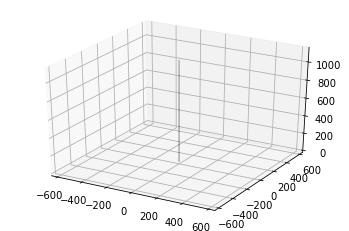

In [9]:
system_3D = makesystem_3D(pm)
system_3D_wrapped = kwant.wraparound.wraparound(system_3D).finalized()
kwant.plot(system_3D, site_size=0.05, site_lw=0.01, hop_lw=0.05);

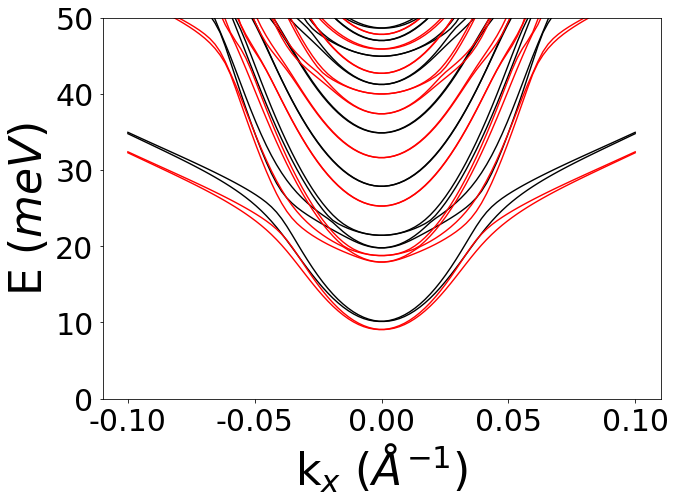

In [49]:
draw(kxs*nm2au(.1), [1000*energies_3D_x/eV2au(1.0),1000*energies_2D_10_x/eV2au(1.0)],
     axis_x = 'k$_{x}$ ($Å^{-1}$)', axis_y = 'E ($meV$)',
     y_range = [0.0, 50.0], color_list = ['k','r'],
     savefigas = '2D_10_x__3D_x')

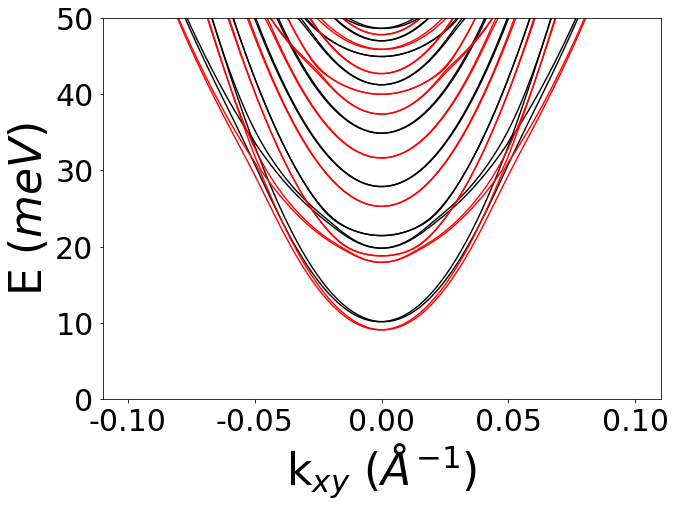

In [50]:
draw(kxs*nm2au(.1), [1000*energies_3D_xy/eV2au(1.0),1000*energies_2D_10_xy/eV2au(1.0)],
     axis_x = 'k$_{xy}$ ($Å^{-1}$)', axis_y = 'E ($meV$)',
     y_range = [0.0, 50.0], color_list = ['k','r'],
     savefigas = '2D_10_xy__3D_xy')